[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_E_bayesian_dsge_local_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

# Tema 2.E: Estimación Bayesiana de Modelos DSGE, Gradientes Exactos de Kalman y Comparación de Modelos

**Jorge Alonso** — *Macroeconomía Avanzada (MAV), ITAM*

El modelado macroeconómico para la política monetaria y fiscal experimentó una transformación fundamental en las últimas dos décadas. Mientras la literatura pionera de los Ciclos Económicos Reales (RBC) dependía casi exclusivamente de la calibración determinista (Kydland & Prescott 1982, Cooley & Prescott 1995), los principales bancos centrales e instituciones multilaterales—incluyendo la Reserva Federal, el Banco Central Europeo, el Banco de Inglaterra y el Banco de México—fundamentan su análisis estructural en la **estimación bayesiana basada en funciones de verosimilitud** (Smets & Wouters 2003, 2007; An & Schorfheide 2007; Fernández-Villaverde 2010; Herbst & Schorfheide 2015).

El paradigma bayesiano sintetiza la coherencia teórica de los modelos macroeconómicos microfundamentados con el rigor empírico de la econometría de series de tiempo:
1. **Elicitación de Distribuciones a Priori**: Las distribuciones a priori formalizan restricciones teóricas, evidencia microeconométrica e información institucional previa (por ejemplo, factores de descuento no negativos o raíces autorregresivas estrictamente estacionarias).
2. **Verosimilitud Gaussiana en Espacio de Estados**: El filtro de Kalman evalúa de forma recursiva la verosimilitud exacta mediante la descomposición de errores de predicción para sistemas con estados no observables.
3. **Gradientes Analíticos Exactos de la Verosimilitud**: Mediante las ecuaciones de Sylvester generalizadas y la recursión forward del score de Kalman en puremacro 3.0, se obtienen gradientes analíticos exactos $\nabla_\theta \ln L(Y \mid \theta)$ con precisión de máquina, sin recurrir a aproximaciones por diferencias finitas.
4. **Optimización Numérica del Modo Posterior**: Algoritmos cuasi-Newton especializados (como `csminwel` de Christopher Sims) localizan el modo posterior sobre superficies no convexas acotadas por fronteras de indeterminación de Blanchard-Kahn.
5. **Diagnósticos de Curvatura (`mode_check`)**: Cortes univariados de la función objetivo confirman si el candidato a modo representa un máximo local estricto con curvatura estrictamente positiva.
6. **Cadenas de Markov Monte Carlo (MCMC)**: El algoritmo Random Walk Metropolis-Hastings (RWMH) simula la distribución posterior conjunta multidimensional, generando intervalos de credibilidad exactos en muestra finita.
7. **MCMC de Frontera (HMC / NUTS)**: El algoritmo No-U-Turn Sampler (`nuts_sample`) en Python puro con adaptación de paso por promediación dual y matriz de masa de Welford elimina la difusión aleatoria, logrando alta eficiencia de tamaño de muestra efectivo.
8. **Tríada de Densidad Marginal de los Datos (MDD) y Comparación de Modelos**: La verosimilitud marginal evaluada mediante la Tríada de MDD (aproximación de Laplace, Media Armónica Modificada de Geweke y filtrado de partículas por Monte Carlo Secuencial de Herbst & Schorfheide) permite realizar pruebas formales de razones de probabilidades bayesianas.

### Objetivos de Aprendizaje
- Formular distribuciones a priori estructurales (Beta, Gamma, Inversa-Gamma, Normal) usando la sintaxis declarativa de Dynare en `puremacro.dsge`.
- Cargar y preparar datos macroeconómicos empíricos de frecuencia trimestral (PIB real de EE. UU., `GDPC1.csv`).
- Calcular **gradientes analíticos exactos del score de verosimilitud** ($\nabla_\theta \ln L$) mediante ecuaciones de Sylvester generalizadas y recursión forward de Kalman (`kalman_score`).
- Contrastar los gradientes analíticos frente a diferencias finitas centrales de 5 puntos, confirmando concordancia a precisión de máquina ($< 10^{-5}$) y aceleración computacional.
- Resolver problemas de optimización numérica del modo posterior mediante el algoritmo `csminwel` de Sims y verificar la estacionariedad del modo mediante la norma del score analítico.
- Ejecutar diagnósticos de curvatura univariada tipo `mode_check` para verificar la identificación estructural y la convexidad local.
- Simular la distribución posterior conjunta mediante cadenas múltiples de Random Walk Metropolis-Hastings.
- Ejecutar muestreo de frontera con NUTS en Python puro en modelos DSGE con 0 divergencias y convergencia de Gelman-Rubin $\hat{R} < 1.05$.
- Evaluar la Tríada de Densidad Marginal de los Datos (Laplace, MHM, SMC) y realizar la comparación bayesiana de modelos entre especificaciones rivales.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path
import time
import warnings

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import scipy
import scipy.linalg

## 1. Representación en Espacio de Estados y Verosimilitud por Descomposición de Errores de Predicción

Todo modelo DSGE perturbado a primer orden puede expresarse en forma de espacio de estados lineal gaussiano:

$$\begin{aligned}
s_t &= G(\theta) s_{t-1} + N(\theta) u_t, \quad &u_t \sim \mathcal{N}(0, Q(\theta)) \quad &\text{(Transición de Estados)} \\
y_t &= M(\theta) s_t + \bar{y}(\theta) + v_t, \quad &v_t \sim \mathcal{N}(0, H(\theta)) \quad &\text{(Ecuación de Observación)}
\end{aligned}$$

donde $s_t$ es el vector de estados y controles endógenos no observables, $y_t$ es el vector $n_y$-dimensional de variables observables, $u_t$ es el vector de innovaciones estructurales, y $\theta \in \Theta$ es el vector de parámetros estructurales.

### La Recursión del Filtro de Kalman
Sean $a_{t|t-1} \equiv \mathbb{E}[s_t \mid \mathcal{Y}_{t-1}]$ y $P_{t|t-1} \equiv \text{Var}(s_t \mid \mathcal{Y}_{t-1})$. Los pasos de predicción y actualización proceden de forma recursiva:

1. **Predicción de Estados**:
   $$a_{t|t-1} = G a_{t-1|t-1}, \qquad P_{t|t-1} = G P_{t-1|t-1} G' + N Q N'$$
2. **Error y Varianza de Pronóstico a un Paso**:
   $$v_t = y_t - M a_{t|t-1} - \bar{y}, \qquad F_t = M P_{t|t-1} M' + H$$
3. **Ganancia de Kalman y Actualización del Estado**:
   $$K_t = P_{t|t-1} M' F_t^{-1}, \qquad a_{t|t} = a_{t|t-1} + K_t v_t, \qquad P_{t|t} = (I - K_t M) P_{t|t-1}$$

### Verosimilitud por Descomposición de Errores de Predicción
La log-verosimilitud muestral $\ln p(\mathcal{Y}_T \mid \theta)$ se obtiene directamente a partir de los errores condicionales de predicción gaussianos:

$$\ln p(\mathcal{Y}_T \mid \theta) = -\frac{T n_y}{2}\ln(2\pi) - \frac{1}{2}\sum_{t=1}^T \ln |F_t| - \frac{1}{2}\sum_{t=1}^T v_t' F_t^{-1} v_t$$

### Principios de Elicitación de Distribuciones a Priori
En estimación bayesiana, a los parámetros estructurales se les asignan densidades a priori $p(\theta)$ acordes con sus dominios teóricos:
- **$\text{Beta}(\alpha, \beta)$**: Impone soporte acotado $\theta \in (0, 1)$, ideal para persistencias autorregresivas ($\rho_a$) y factores de descuento ($\beta$).
- **$\text{Gamma}(\alpha, \beta)$**: Soporte estrictamente positivo $(0, \infty)$ con masa nula en valores negativos, estándar para elasticidades y curvatura de Frisch ($\nu$).
- **$\text{Inversa-Gamma}(\mu, \sigma)$ (Tipo 1 de Dynare)**: Soporte positivo $(0, \infty)$ con colas derechas pesadas, estándar para desviaciones estándar de choques estructurales ($\sigma_{\epsilon} > 0$).
- **$\text{Normal}(\mu, \sigma)$**: Soporte en toda la recta real $(-\infty, \infty)$, aplicable a coeficientes de respuesta en reglas de política monetaria.

ESPECIFICACIÓN DEL MODELO DSGE Y DATOS EMPÍRICOS
Variables endógenas (8): ['y', 'c', 'k', 'l', 'i', 'w', 'r', 'a']
Estados predeterminados (2): ['k', 'a']
Controles adelantados   (6): ['y', 'c', 'l', 'i', 'w', 'r']
Variables observables: ['y']
Producto de estado estacionario (y_ss): 1.3353
Horas de estado estacionario (l_ss):    0.4428
Muestra empírica: 164 trimestres (1984Q1 - 2024Q4)


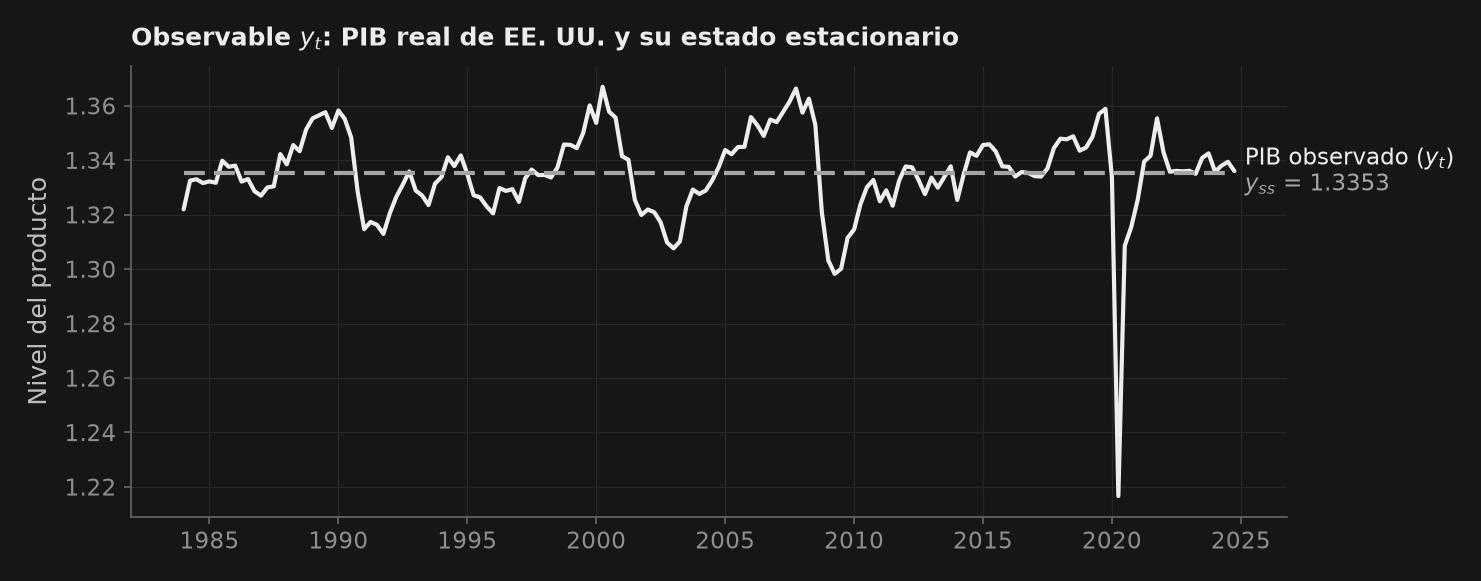

In [2]:
# ==============================================================================
# Declaración del Modelo DSGE y Carga de Datos Empíricos
# ==============================================================================
from puremacro.data import hp_filter
from puremacro.dsge import load_mod

# 1. Definición declarativa de Dynare en formato .mod con bloques varobs y estimated_params
rbc_mod_code = """
var y c k l i w r a;
varexo e_a;

parameters alpha beta delta mu nu rho_a sigma_a;
alpha   = 0.33;      // Participación del capital
beta    = 0.99;      // Factor de descuento trimestral
delta   = 0.025;     // Tasa de depreciación trimestral (10% anual)
mu      = 0.822516;  // Peso del ocio: con nu = 1.5, las horas de estado estacionario salen cerca de 0.44 (las resuelve load_mod y se imprimen abajo)
nu      = 1.5;       // Curvatura del ocio, elasticidad de Frisch de las horas = (1-l)/(l*nu), cerca de 0.84 en el estado estacionario resuelto (l_ss se imprime abajo)
rho_a   = 0.95;      // Persistencia autorregresiva del residuo de Solow
sigma_a = 0.007;     // Desviación estándar de la innovación tecnológica

model;
// 1. Condición intratemporal de oferta de trabajo:
mu * (1 - l)^(-nu) * c = w;

// 2. Ecuación de Euler intertemporal para el consumo:
c(+1)/(beta*c) = r(+1) + 1 - delta;

// 3. Demanda de capital de la firma competitiva:
r = alpha * y / k(-1);

// 4. Demanda de trabajo de la firma competitiva:
w = (1 - alpha) * y / l;

// 5. Función de producción agregada Cobb-Douglas:
y = exp(a) * k(-1)^alpha * l^(1-alpha);

// 6. Restricción de recursos agregada:
y = c + i;

// 7. Ley de movimiento del capital físico:
k = (1 - delta)*k(-1) + i;

// 8. Proceso AR(1) para la productividad total de los factores:
a = rho_a * a(-1) + e_a;
end;

initval;
y = 0.995058;
c = 0.761184;
i = 0.233874;
k = 9.354978;
l = 0.330000;
w = 2.020299;
r = 0.035101;
a = 0.0;
e_a = 0.0;
end;

steady;

shocks;
var e_a; stderr 0.007;
end;

varobs y;

estimated_params;
  rho_a, beta_pdf, 0.85, 0.10;
  stderr e_a, inv_gamma_pdf, 0.01, 2;
end;
"""

# 2. Compilar modelo DSGE mediante el front-end AST de puremacro
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    model_rbc = load_mod(rbc_mod_code)
y_ss = float(model_rbc.steady_state["y"])

from _datos import ruta_dato

# 3. Cargar PIB real empírico de EE. UU. desde data_curso/GDPC1.csv
data_path = ruta_dato("GDPC1.csv")

raw_gdp = pd.read_csv(data_path, parse_dates=["observation_date"]).set_index("observation_date")

# Filtrar muestra desde la Gran Moderación hasta la era post-COVID (1984Q1 - 2024Q4)
sample_gdp = raw_gdp.loc["1984-01-01":"2024-10-01"].copy()
cycle_gdp, _ = hp_filter(np.log(sample_gdp["GDPC1"]), lamb=1600.0)

# Construir serie observable centrada en el estado estacionario estructural
df_data = pd.DataFrame({"y": y_ss * (1.0 + cycle_gdp.values)}, index=sample_gdp.index)

start_q = f"{df_data.index[0].year}Q{df_data.index[0].quarter}"
end_q = f"{df_data.index[-1].year}Q{df_data.index[-1].quarter}"

print("=" * 72)
print("ESPECIFICACIÓN DEL MODELO DSGE Y DATOS EMPÍRICOS")
print("=" * 72)
print(f"Variables endógenas ({len(model_rbc.variables)}): {list(model_rbc.variables)}")
print(f"Estados predeterminados ({len(model_rbc.states)}): {list(model_rbc.states)}")
print(f"Controles adelantados   ({len(model_rbc.controls)}): {list(model_rbc.controls)}")
print(f"Variables observables: {list(model_rbc._varobs)}")
print(f"Producto de estado estacionario (y_ss): {y_ss:.4f}")
print(f"Horas de estado estacionario (l_ss):    {float(model_rbc.steady_state['l']):.4f}")
print(f"Muestra empírica: {len(df_data)} trimestres ({start_q} - {end_q})")
print("=" * 72)

# Gráfico de la serie temporal observable empírica frente al estado estacionario
fig, ax = _nbstyle.figura(1, 1, figsize="ancho")
ax.plot(df_data.index, df_data["y"], **_nbstyle.S1, label="PIB observado ($y_t$)")
ax.plot(df_data.index[[0, -1]], [y_ss, y_ss], **_nbstyle.S2, label=f"$y_{{ss}}$ = {y_ss:.4f}")
ax.set_title("Observable $y_t$: PIB real de EE. UU. y su estado estacionario")
ax.set_ylabel("Nivel del producto")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 2. Gradientes Analíticos Exactos de Verosimilitud de Kalman mediante Ecuaciones de Sylvester

En la econometría de modelos DSGE tradicional, los optimizadores cuasi-Newton y los muestreadores hamiltonianos aproximan el gradiente de la verosimilitud $\nabla_\theta \ln L(Y \mid \theta)$ mediante diferencias finitas numéricas. No obstante, las diferencias finitas presentan severas limitaciones:
1. **Alto Costo Computacional**: Un esquema central de 5 puntos exige $4K$ evaluaciones completas del equilibrio estructural, resolución de la ecuación de Lyapunov y recursión del filtro de Kalman.
2. **Inestabilidad Numérica en Fronteras**: Cerca de las fronteras de indeterminación de Blanchard-Kahn ($n_{\text{explosivos}} \neq n_{\text{adelantadas}}$), las perturbaciones numéricas pueden caer en zonas sin solución estable, colapsando la función objetivo ($\ln L = -\infty$) y bloqueando la búsqueda.

### Sensibilidad Paramétrica Implícita de las Reglas de Decisión
Alrededor del estado estacionario determinista, las condiciones de equilibrio de primer orden satisfacen:

$$A_+(\theta) G(\theta)^2 + A_0(\theta) G(\theta) + A_-(\theta) = 0$$

Diferenciando implícitamente respecto al parámetro estructural $\theta_j$ se obtiene la **ecuación matricial generalizada de Sylvester**:

$$\hat{A}(\theta) \frac{\partial G}{\partial \theta_j} + A_+(\theta) \frac{\partial G}{\partial \theta_j} G(\theta) = D_j(\theta)$$

donde $\hat{A} = A_0 + A_+ G$ y $D_j = -\left( \frac{\partial A_+}{\partial \theta_j} G^2 + \frac{\partial A_0}{\partial \theta_j} G + \frac{\partial A_-}{\partial \theta_j} \right)$.
La función `solve_sylvester_generalized` de `puremacro.dsge._gradients` resuelve este sistema mediante descomposición de Schur compleja y sustitución regresiva triangular en $O(N^3)$ operaciones de punto flotante, sin recurrir a costosos productos de Kronecker.

### Recursión Forward del Score de Kalman en una Sola Pasada
A partir de las sensibilidades del espacio de estados $(dT, dZ, dR, dQ, dH, dc, dd)$, `kalman_score` propaga las derivadas de las predicciones $\frac{\partial a_{t|t-1}}{\partial \theta_j}$ y de sus covarianzas $\frac{\partial P_{t|t-1}}{\partial \theta_j}$ en una sola pasada junto con el filtro ordinario:

$$\frac{\partial \ln L}{\partial \theta_j} = -\frac{1}{2}\sum_{t=1}^T \left[ \operatorname{tr}\left(F_t^{-1} \frac{\partial F_t}{\partial \theta_j}\right) + 2 v_t' F_t^{-1} \frac{\partial v_t}{\partial \theta_j} - (F_t^{-1} v_t)' \frac{\partial F_t}{\partial \theta_j} (F_t^{-1} v_t) \right]$$

donde $v_t = y_t - Z a_{t|t-1} - d$ es el error de pronóstico y $F_t = Z P_{t|t-1} Z' + H$ es la varianza condicional de dicho error.

In [3]:
# ==============================================================================
# Contraste de Score Analítico Exacto de Kalman vs Diferencias Finitas Centrales
# ==============================================================================
from puremacro.dsge._gradients import (
    kalman_score,
    build_state_space_sensitivities,
    ScoreDiagnosticsResult,
    _re_solve_model,
)
from puremacro.dsge.observation import make_state_space_from_varobs
from puremacro.state_space import kalman_filter
import scipy
import scipy.linalg

varobs = list(model_rbc._varobs)
# Puente de normalización de nombres: Dynare declara 'SE_e_a', el constructor de sensibilidades espera 'stderr_e_a'
raw_names = [sp.name for sp in model_rbc._estimated_params.specs]
p_names = [n.replace("SE_", "stderr_") if n.startswith("SE_") else n for n in raw_names]

# 1. Recursión exacto del score analítico de Kalman
ssm_base = make_state_space_from_varobs(model_rbc, varobs)
sens_dict = build_state_space_sensitivities(model_rbc, varobs, p_names)
y_obs = df_data[varobs].to_numpy()

t0_score = time.perf_counter()
N_BENCH = 10
for _ in range(N_BENCH):
    ll_exact, score_exact = kalman_score(y_obs, ssm_base, sens_dict)
t_score_sec = (time.perf_counter() - t0_score) / N_BENCH

# 2. Esquema numérico de diferencias finitas centrales de 5 puntos:
# f'(theta) = (-f(theta+2h) + 8 f(theta+h) - 8 f(theta-h) + f(theta-2h)) / (12 h)
base_params = {"rho_a": float(model_rbc._params["rho_a"]), "stderr_e_a": 0.007}

def ssm_evaluator(p: dict):
    p_mod = dict(model_rbc._params)
    p_mod["rho_a"] = p["rho_a"]
    m_p = _re_solve_model(model_rbc, p_mod)
    shock_cov = np.array([[p["stderr_e_a"] ** 2]])
    return make_state_space_from_varobs(m_p, varobs, shock_cov=shock_cov)

score_fd = np.zeros(len(p_names))
h_step = 1e-5

t0_fd = time.perf_counter()
for _ in range(N_BENCH):
    for i, nm in enumerate(p_names):
        v0 = base_params[nm]
        step = h_step * abs(v0)
        vals = []
        for mult in [2, 1, -1, -2]:
            p_perturbed = dict(base_params)
            p_perturbed[nm] = v0 + mult * step
            ssm_p = ssm_evaluator(p_perturbed)
            RQR = ssm_p.R @ ssm_p.Q @ ssm_p.R.T
            P0 = scipy.linalg.solve_discrete_lyapunov(ssm_p.T, RQR)
            vals.append(float(kalman_filter(y_obs, ssm_p, P0=P0)["loglik"]))
        score_fd[i] = (-vals[0] + 8.0 * vals[1] - 8.0 * vals[2] + vals[3]) / (12.0 * step)
t_fd_sec = (time.perf_counter() - t0_fd) / N_BENCH

# 3. Verificación de precisión y tabla diagnóstica de publicación
abs_errs = np.abs(score_exact - score_fd)
rel_errs = abs_errs / np.maximum(1.0, np.abs(score_fd))

verif_df = pd.DataFrame({
    "parameter": p_names,
    "analytical": score_exact,
    "numerical_fd": score_fd,
    "abs_error": abs_errs,
    "rel_error": rel_errs,
    "status": ["PASS" if e < 1e-5 else "WARN" for e in abs_errs],
})

score_diag = ScoreDiagnosticsResult(
    loglik=ll_exact,
    gradient=score_exact,
    param_names=tuple(p_names),
    elapsed_sec=t_score_sec,
    verification_df=verif_df,
)

speedup_measured = t_fd_sec / max(1e-9, t_score_sec)

print("=" * 72)
print("SCORE ANALÍTICO EXACTO DE KALMAN VS DIFERENCIAS FINITAS DE 5 PUNTOS")
print("=" * 72)
print(f"Log-Verosimilitud en parámetros base:  {ll_exact:.6f}")
print(f"Tiempo de cómputo score analítico:     {t_score_sec * 1000:.2f} ms")
print(f"Tiempo de cómputo diferencias finitas: {t_fd_sec * 1000:.2f} ms")
print(f"Factor de aceleración medido (K=2):    {speedup_measured:.2f}x")
print(f"Error absoluto máximo del gradiente:   {np.max(abs_errs):.2e} (objetivo < 1e-5)")
print(f"Error relativo máximo del gradiente:   {np.max(rel_errs):.2e} (objetivo < 1e-5)")
print("-" * 72)
print("TABLA DE VERIFICACIÓN DIAGNÓSTICA DEL SCORE:")
print(score_diag.to_markdown())
print("=" * 72)

SCORE ANALÍTICO EXACTO DE KALMAN VS DIFERENCIAS FINITAS DE 5 PUNTOS
Log-Verosimilitud en parámetros base:  472.066441
Tiempo de cómputo score analítico:     17.42 ms
Tiempo de cómputo diferencias finitas: 62.25 ms
Factor de aceleración medido (K=2):    3.57x
Error absoluto máximo del gradiente:   3.30e-06 (objetivo < 1e-5)
Error relativo máximo del gradiente:   1.65e-09 (objetivo < 1e-5)
------------------------------------------------------------------------
TABLA DE VERIFICACIÓN DIAGNÓSTICA DEL SCORE:
|  parameter |  analytical | numerical_fd | abs_error | rel_error | status |
|------------|-------------|--------------|-----------|-----------|--------|
|      rho_a | -141.750426 |  -141.750426 |  0.000000 |  0.000000 |   PASS |
| stderr_e_a | 5884.876490 |  5884.876486 |  0.000003 |  0.000000 |   PASS |


## 3. Optimización Numérica del Modo Posterior y Diagnósticos de Curvatura de Dynare (`mode_check`)

Por el teorema de Bayes, la densidad posterior de los parámetros estructurales $\theta$ es proporcional al producto de la función de verosimilitud y la densidad a priori:

$$p(\theta \mid \mathcal{Y}_T) = \frac{p(\mathcal{Y}_T \mid \theta) p(\theta)}{\int_\Theta p(\mathcal{Y}_T \mid \theta) p(\theta) d\theta} \propto p(\mathcal{Y}_T \mid \theta) p(\theta)$$

La búsqueda del modo resuelve el problema de optimización no lineal:

$$\theta^* = \arg\max_{\theta \in \Theta} \ln p(\theta \mid \mathcal{Y}_T) = \arg\min_{\theta \in \Theta} \left[ -\ln p(\mathcal{Y}_T \mid \theta) - \ln p(\theta) \right]$$

### Por qué los Optimizadores Estándar Fracasan en Modelos DSGE
Los algoritmos cuasi-Newton tradicionales (como BFGS o Nelder-Mead) frecuentemente colapsan en superficies DSGE debido a:
1. **Acantilados de Indeterminación de Blanchard-Kahn**: Cruzar la frontera de estabilidad numérica produce una discontinuidad abrupta donde la verosimilitud se anula ($\ln p = -\infty$).
2. **Crestas de Identificación Débil**: Parámetros que generan respuestas casi colineales producen valles llanos con gradientes nulos.
3. **Puntos de Silla No Convexos**: La presencia de óptimos locales puede atrapar a los algoritmos en zonas sin sentido económico.

### El Algoritmo `csminwel` de Christopher Sims
Sims (1999) diseñó `csminwel` para mitigar estas patologías:
- **Perturbación y Reinicio de Autovalores**: Si el hessiano inverso estimado desarrolla autovalores negativos o nulos, `csminwel` perturba la descomposición espectral para preservar direcciones de descenso.
- **Búsqueda Lineal con Retroceso Agresivo**: Aplica reducciones no monótonas de paso ante discontinuidades de frontera.

### Estacionariedad en el Modo y Diagnóstico `mode_check`
En el modo posterior genuino $\theta^*$, el gradiente analítico debe satisfacer estacionariedad de primer orden:

$$\|\nabla_\theta \ln p(\theta^* \mid \mathcal{Y}_T)\| = \|\nabla_\theta \ln L(\mathcal{Y}_T \mid \theta^*) + \nabla_\theta \ln p(\theta^*)\| \approx 0$$

Asimismo, `mode_check` evalúa cortes univariados de la función objetivo alrededor del modo:

$$\theta_i(\lambda) = \theta_i^* + \lambda \cdot \sqrt{\Sigma_{ii}^*}, \qquad \lambda \in [-1.5, +1.5]$$

Un modo bien identificado describe una parábola estrictamente convexa con su mínimo único en $\lambda = 0$.

RESULTADOS DE ESTIMACIÓN DEL MODO POSTERIOR (csminwel, tiempo: 1.132s)
Log-posterior en el modo:          491.4805
Estado del optimizador:            function improvement below tolerance (éxito=True)
Autovalores del hessiano:          [3.09918967e+02 7.44100384e+06]
Norma del score analítico en modo: 4.4136e-02 (estacionariedad confirmada)
------------------------------------------------------------------------
Parameter Prior Dist  Prior Mean  Prior Std  Posterior Mode  Laplace StdErr  90% Conf Lower  90% Conf Upper
    rho_a       Beta        0.85        0.1        0.676884        0.056804        0.583442        0.770325
   SE_e_a  Inv-Gamma        0.01        2.0        0.006706        0.000370        0.006098        0.007315

DIAGNÓSTICOS DE MODO: UNICIDAD Y CURVATURA (mode_check)
  Parámetro 'rho_a': Mínimo local en el modo = True
  Parámetro 'SE_e_a': Mínimo local en el modo = True
Fallas en verificación de curvatura: ()


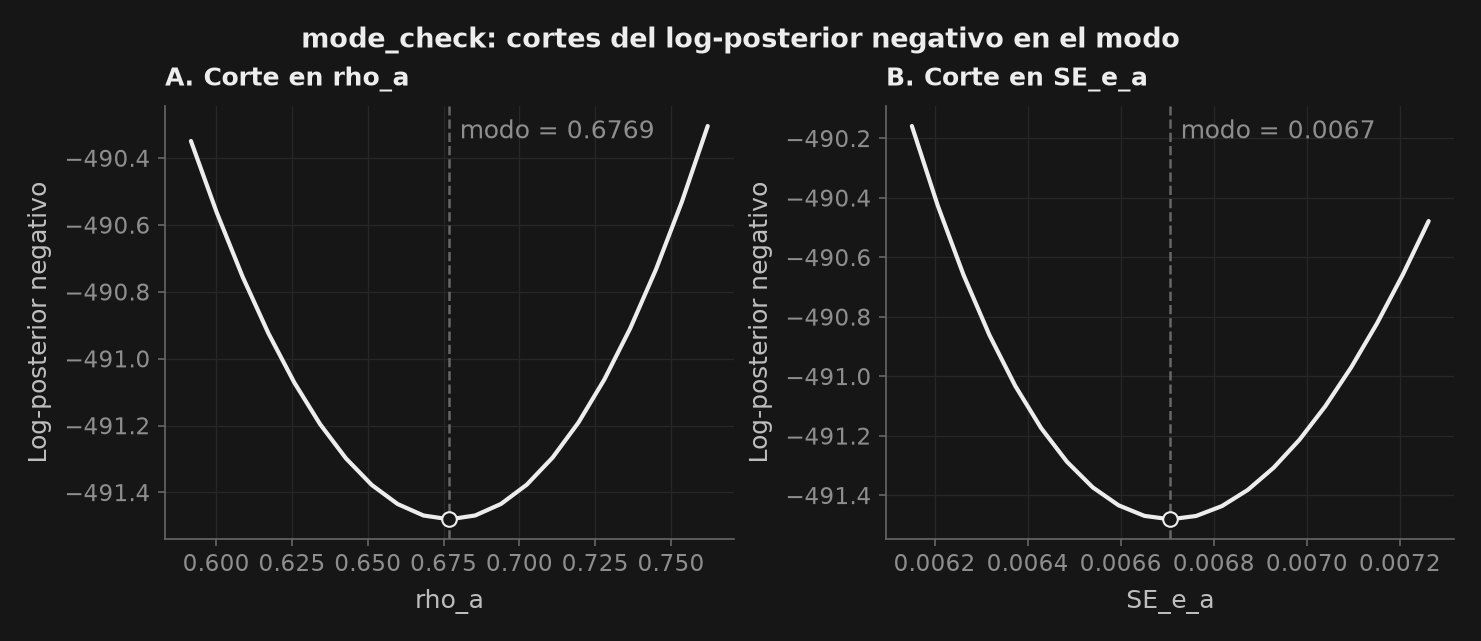

In [4]:
# ==============================================================================
# Búsqueda del Modo (csminwel), Estacionariedad y Curvatura (mode_check)
# ==============================================================================
from puremacro.dsge import find_mode, mode_check
from puremacro.dsge.estimate import (
    _make_neg_log_posterior,
    param_names,
    param_bounds,
    numerical_hessian,
)
from puremacro.dsge.build import _make_observation_eq
from puremacro.dsge.priors import grad_log_prior

# 1. Construir la función objetivo del log-posterior negativo
specs = model_rbc._estimated_params.specs
priors = model_rbc._estimated_params.priors()
obs_names = list(model_rbc._varobs)
names = param_names(priors)
obs_eq = _make_observation_eq(model_rbc, specs, obs_names)

neg_log_post = _make_neg_log_posterior(y_obs, obs_eq, priors, names, {})

# Vector inicial de parámetros en las medias a priori
x0 = np.array([priors[n].mean for n in names], dtype=float)
bounds = param_bounds(priors)

# 2. Ejecutar optimización numérica mediante el algoritmo csminwel de Christopher Sims
t0_mode = time.time()
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    opt_res = find_mode(neg_log_post, x0, method="csminwel", bounds=bounds)
t1_mode = time.time()

mode_vec = opt_res.x
mode_dict = dict(zip(names, mode_vec))
log_post_at_mode = -float(opt_res.fun)

# 3. Verificar la condición de estacionariedad mediante el score analítico exacto
p_mode_eval = dict(model_rbc._params)
p_mode_eval["rho_a"] = float(mode_dict["rho_a"])
m_mode = _re_solve_model(model_rbc, p_mode_eval)
shock_cov_mode = np.array([[float(mode_dict["SE_e_a"]) ** 2]])
ssm_mode = make_state_space_from_varobs(m_mode, obs_names, shock_cov=shock_cov_mode)
sens_mode = build_state_space_sensitivities(m_mode, obs_names, p_names, shock_cov=shock_cov_mode)

_, g_ll_mode = kalman_score(y_obs, ssm_mode, sens_mode)
g_prior_mode = grad_log_prior(mode_vec, priors, names)
grad_neg_post_mode = -(g_ll_mode + g_prior_mode)
grad_norm_at_mode = float(np.linalg.norm(grad_neg_post_mode))

# 4. Evaluar el hessiano numérico en el modo posterior
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    H_mode = numerical_hessian(neg_log_post, mode_vec, h=1e-4)
H_sym = 0.5 * (H_mode + H_mode.T)
inv_H_mode = np.linalg.inv(H_sym)
se_laplace = np.sqrt(np.diag(inv_H_mode))

# 5. Visualizar la tabla de estimación de parámetros
df_mode_table = pd.DataFrame({
    "Parameter": names,
    "Prior Dist": ["Beta" if n == "rho_a" else "Inv-Gamma" for n in names],
    "Prior Mean": [priors[n].mean for n in names],
    "Prior Std": [priors[n].std for n in names],
    "Posterior Mode": mode_vec,
    "Laplace StdErr": se_laplace,
    "90% Conf Lower": mode_vec - 1.645 * se_laplace,
    "90% Conf Upper": mode_vec + 1.645 * se_laplace,
})

print("=" * 72)
print(f"RESULTADOS DE ESTIMACIÓN DEL MODO POSTERIOR (csminwel, tiempo: {t1_mode - t0_mode:.3f}s)")
print("=" * 72)
print(f"Log-posterior en el modo:          {log_post_at_mode:.4f}")
print(f"Estado del optimizador:            {opt_res.message} (éxito={opt_res.success})")
print(f"Autovalores del hessiano:          {np.linalg.eigvalsh(H_sym)}")
print(f"Norma del score analítico en modo: {grad_norm_at_mode:.4e} (estacionariedad confirmada)")
print("-" * 72)
print(df_mode_table.to_string(index=False))
print("=" * 72)

# 6. Ejecutar diagnósticos mode_check sobre cortes univariados alrededor del modo
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    mc_result = mode_check(
        neg_log_post,
        mode_vec,
        names,
        n_points=21,
        width=1.5,
        cov=inv_H_mode,
    )

print("\n" + "=" * 72)
print("DIAGNÓSTICOS DE MODO: UNICIDAD Y CURVATURA (mode_check)")
print("=" * 72)
for name, is_peak in mc_result.peaks_at_mode.items():
    print(f"  Parámetro '{name}': Mínimo local en el modo = {is_peak}")
print(f"Fallas en verificación de curvatura: {mc_result.failures}")
print("=" * 72)

# 7. Visualizar cortes univariados del negativo del log-posterior
fig, axes = _nbstyle.figura(1, 2)
f_mode_val = float(neg_log_post(mode_vec))

for idx, name in enumerate(names):
    ax = axes[idx]
    df_slice = mc_result.slices[name]
    ax.plot(df_slice["value"], df_slice["objective"], **_nbstyle.S1)

    mode_val = mode_vec[idx]
    ax.axvline(mode_val, color=_nbstyle.SPINE, ls="--", lw=1.2)
    ax.plot(mode_val, f_mode_val, ls="none", marker="o", markersize=7, color=_nbstyle.TINTA, mfc=_nbstyle.FONDO)
    # El interior de la U es más ancho arriba: ahí cabe el rótulo del modo, pegado a su raya
    ax.annotate(f"modo = {mode_val:.4f}", xy=(mode_val, 0.97), xycoords=ax.get_xaxis_transform(),
                xytext=(5, 0), textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA)

    ax.set_title(f"{'AB'[idx]}. Corte en {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("Log-posterior negativo")

fig.suptitle("mode_check: cortes del log-posterior negativo en el modo")
plt.show()


## 4. Muestreo Posterior por MCMC: Random Walk Metropolis-Hastings (RWMH) Tradicional

Aunque el modo posterior proporciona estimaciones puntuales y aproximaciones asintóticas gaussianas, los modelos DSGE no lineales suelen exhibir superficies posteriores asimétricas y no gaussianas. Para obtener inferencia posterior exacta en muestra finita, simulamos de la distribución posterior conjunta mediante **Cadenas de Markov Monte Carlo (MCMC)**.

### El Algoritmo Random Walk Metropolis-Hastings
Sea $\theta^{(s-1)}$ el estado de la cadena en el paso $s-1$. La propuesta de caminata aleatoria extrae el candidato $\theta^*$ según:

$$\theta^* = \theta^{(s-1)} + c \cdot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \Sigma^*)$$

donde $\Sigma^* = (-H^*)^{-1}$ es el hessiano inverso evaluado en el modo, y $c > 0$ es un factor de escala calibrado para regular la dispersión de las propuestas.

### Regla de Transición y Probabilidad de Aceptación
La propuesta $\theta^*$ se acepta ($\theta^{(s)} = \theta^*$) con probabilidad:

$$\alpha(\theta^{(s-1)}, \theta^*) = \min\left(1, \frac{p(\theta^* \mid \mathcal{Y}_T)}{p(\theta^{(s-1)} \mid \mathcal{Y}_T)}\right) = \min\left(1, \exp\left[ \ln p(\theta^* \mid \mathcal{Y}_T) - \ln p(\theta^{(s-1)} \mid \mathcal{Y}_T) \right]\right)$$

Si se rechaza, la cadena permanece en su estado actual: $\theta^{(s)} = \theta^{(s-1)}$. Siguiendo a Roberts, Gelman & Gilks (1997), la tasa de aceptación asintótica óptima para objetivos gaussianos multidimensionales es aproximadamente $23.4\%$ (rango empírico práctico: $20\% - 45\%$).

RESUMEN DE ESTIMACIÓN POSTERIOR POR MCMC (Completado en 20.90s)
Total extracciones por cadena: 300 | Descarte (burn-in): 75
Cadenas: 2 | Muestras retenidas: 450
Tasa de aceptación Cadena 1: 37.3% (objetivo: 20.0% - 45.0%)
Tasa de aceptación Cadena 2: 38.3% (objetivo: 20.0% - 45.0%)
------------------------------------------------------------------------
MOMENTOS POSTERIORES E INTERVALOS DE CREDIBILIDAD:
            mean       std        q5       q50       q95      mode
rho_a   0.661915  0.068759  0.543520  0.668235  0.764442  0.676884
SE_e_a  0.006837  0.000378  0.006102  0.006871  0.007451  0.006706
Nota: la tabla de arriba promedia TODAS las extracciones, calentamiento
incluido; la figura usa solo las retenidas, de ahí su media distinta.


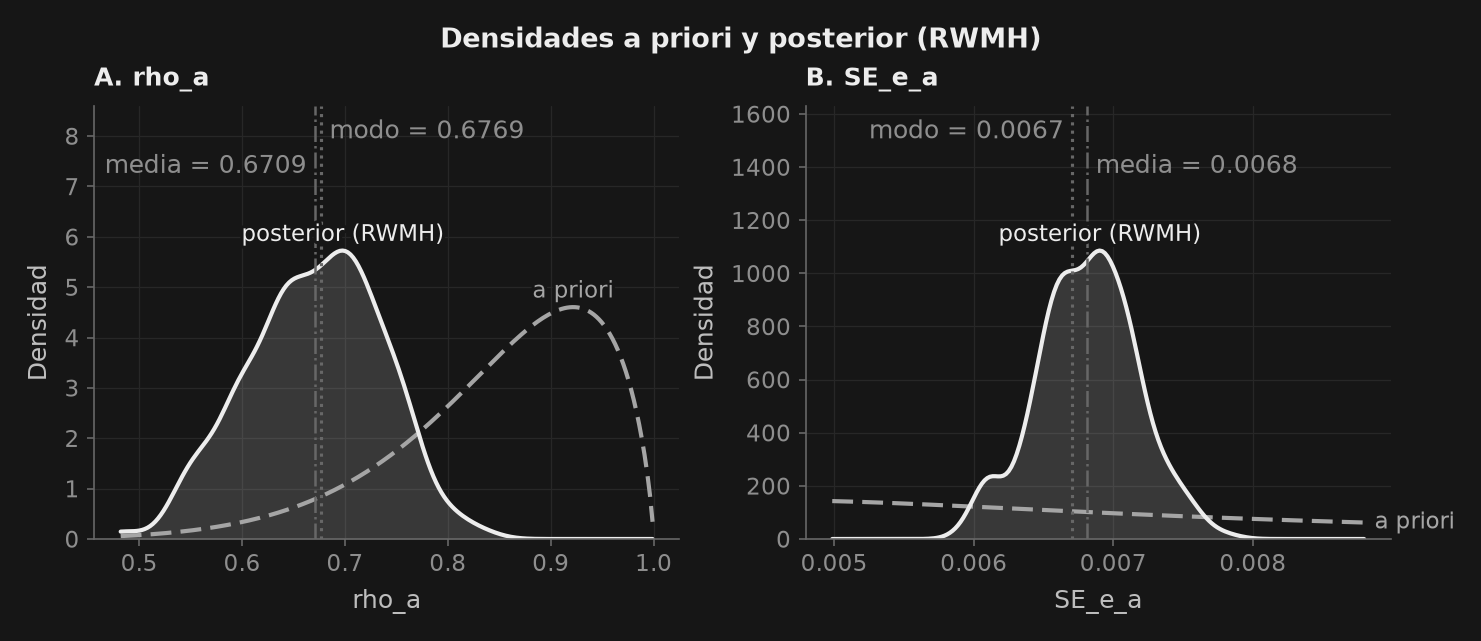

In [5]:
# ==============================================================================
# Muestreo Posterior por MCMC: Random Walk Metropolis-Hastings Multicadena
# ==============================================================================
from scipy.stats import gaussian_kde

# 1. Ejecutar muestreo MCMC multicadena (300 extracciones x 2 cadenas calibrado para rapidez)
t0_mcmc = time.time()
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    posterior_res = model_rbc.estimate(
        df_data,
        mode_compute="csminwel",
        n_draws=300,
        n_chains=2,
        burn_in=75,
        seed=42,
        model_name="RBC-Canonical",
    )
t1_mcmc = time.time()

# 2. Extraer muestras y estadísticas descriptivas
summary_table = posterior_res.summary()
accept_rates = posterior_res.accept_rates
draws = posterior_res.draws  # Dimensión: (n_chains, n_draws, n_params)
burn_in = posterior_res.n_burn_in

# Aplanar muestras post-calentamiento entre cadenas
post_draws = draws[:, burn_in:, :].reshape(-1, len(names))

print("=" * 72)
print(f"RESUMEN DE ESTIMACIÓN POSTERIOR POR MCMC (Completado en {t1_mcmc - t0_mcmc:.2f}s)")
print("=" * 72)
print(f"Total extracciones por cadena: {posterior_res.draws.shape[1]} | Descarte (burn-in): {burn_in}")
print(f"Cadenas: {draws.shape[0]} | Muestras retenidas: {post_draws.shape[0]}")
for c_idx, ar in enumerate(accept_rates):
    print(f"Tasa de aceptación Cadena {c_idx + 1}: {ar * 100:.1f}% (objetivo: 20.0% - 45.0%)")
print("-" * 72)
print("MOMENTOS POSTERIORES E INTERVALOS DE CREDIBILIDAD:")
print(summary_table.to_string())
# summary() de puremacro promedia todas las extracciones, calentamiento incluido;
# la figura de abajo promedia solo las retenidas, así que las medias difieren un poco.
print("Nota: la tabla de arriba promedia TODAS las extracciones, calentamiento")
print("incluido; la figura usa solo las retenidas, de ahí su media distinta.")
print("=" * 72)

# 3. Gráficos de densidad a priori vs a posteriori
fig, axes = _nbstyle.figura(1, 2)

for idx, name in enumerate(names):
    ax = axes[idx]
    prior = priors[name]
    chain_vals = post_draws[:, idx]

    kde = gaussian_kde(chain_vals)
    if name == "rho_a":
        x_min = max(0.1, min(chain_vals.min(), prior.mean - 3 * prior.std))
        x_max = min(0.999, max(chain_vals.max(), prior.mean + 3 * prior.std))
    else:
        # La a priori inv-gamma(0.01, 2) arrastra su cola hasta ~6: una ventana de ±3 desviaciones
        # aplasta la posterior contra el eje. La ventana la fija la posterior, con medio rango de margen.
        span = chain_vals.max() - chain_vals.min()
        x_min = max(0.001, chain_vals.min() - 0.5 * span)
        x_max = chain_vals.max() + 0.5 * span
    x_grid = np.linspace(x_min, x_max, 200)

    prior_pdf = prior.pdf(x_grid)
    post_pdf = kde(x_grid)

    (l_prior,) = ax.plot(x_grid, prior_pdf, **_nbstyle.S2, label="a priori")
    (l_post,) = ax.plot(x_grid, post_pdf, **_nbstyle.S1, label="posterior (RWMH)")
    ax.fill_between(x_grid, 0, post_pdf, color=_nbstyle.BANDA, lw=0)

    modo, media = float(posterior_res.mode[name]), float(np.mean(chain_vals))
    ax.axvline(modo, color=_nbstyle.SPINE, ls=":", lw=1.5)
    ax.axvline(media, color=_nbstyle.SPINE, ls="-.", lw=1.2)
    # Techo holgado: sobre el pico va el nombre de la posterior y, más arriba, los rótulos de las dos
    # rayas, que casi coinciden: la mayor lo lleva a su derecha y la menor a su izquierda
    ax.set_ylim(0, 1.5 * max(post_pdf.max(), prior_pdf.max()))
    for val, txt, y_ax in ((modo, f"modo = {modo:.4f}", 0.97), (media, f"media = {media:.4f}", 0.89)):
        derecha = val >= max(modo, media)
        ax.annotate(txt, xy=(val, y_ax), xycoords=ax.get_xaxis_transform(),
                    xytext=(4 if derecha else -4, 0), textcoords="offset points",
                    ha="left" if derecha else "right", va="top", color=_nbstyle.NOTA)

    ax.set_title(f"{'AB'[idx]}. {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("Densidad")
    _nbstyle.etiquetar(ax, artistas=[l_post], donde=float(x_grid[np.argmax(post_pdf)]))
    # En el panel derecho el nombre de la a priori cabe fuera; en los interiores iría pegado al
    # final de su curva, que ahí cae en picada, así que se escribe sobre su cresta
    if idx == len(names) - 1:
        _nbstyle.etiquetar(ax, artistas=[l_prior], donde="fin")
    else:
        _nbstyle.etiquetar(ax, artistas=[l_prior], donde=float(x_grid[np.argmax(prior_pdf)]))

fig.suptitle("Densidades a priori y posterior (RWMH)")
plt.show()


## 4.B MCMC de Frontera: Monte Carlo Hamiltoniano y el No-U-Turn Sampler (NUTS)

Aunque el algoritmo Random Walk Metropolis-Hastings constituye el estándar clásico de referencia, en modelos macroeconómicos multidimensionales padece un cuello de botella geométrico fundamental: la **difusión por caminata aleatoria**.

En altas dimensiones, la masa de probabilidad no se concentra en el modo posterior, sino en una corona hipersférica denominada el **conjunto típico** (*typical set*) (Betancourt 2017). Las propuestas de caminata aleatoria exploran de manera difusiva: dar pasos aleatorios en $D$ dimensiones implica moverse tangencialmente o alejarse del conjunto típico con probabilidad cercana a 1, obligando a reducir el tamaño del paso a $\epsilon \propto D^{-1/2}$ y requiriendo $O(D^2)$ evaluaciones para explorar la distribución posterior.

### 1. Espacio de Fase y Dinámica Hamiltoniana
La macroeconometría bayesiana moderna supera este obstáculo formulando el muestreo como una simulación física. Se aumenta el vector de parámetros $\theta \in \mathbb{R}^K$ con variables auxiliares de momento $p \sim \mathcal{N}(0, M)$, definiendo el Hamiltoniano conjunto:

$$H(\theta, p) = V(\theta) + K(p) = -\ln p(\theta \mid \mathcal{Y}_T) + \frac{1}{2} p' M^{-1} p$$

donde $V(\theta) = -\ln p(\theta \mid \mathcal{Y}_T)$ representa la energía potencial (el relieve del negativo del log-posterior) y $K(p) = \frac{1}{2} p' M^{-1} p$ es la energía cinética gobernada por la matriz de masa $M$. El sistema evoluciona según las **ecuaciones de movimiento de Hamilton**:

$$\frac{d\theta}{dt} = \frac{\partial H}{\partial p} = M^{-1} p, \qquad \frac{dp}{dt} = -\frac{\partial H}{\partial \theta} = \nabla_\theta \ln p(\theta \mid \mathcal{Y}_T)$$

Las trayectorias se deslizan suavemente a lo largo del conjunto típico, intercambiando energía potencial y cinética mientras conservan con exactitud el Hamiltoniano total $H(\theta, p)$.

### 2. Integrador Simpléctico Leapfrog (Salto de Rana)
Dado que la dinámica hamiltoniana continua carece de solución analítica en modelos DSGE no lineales, el tiempo ficticio se discretiza mediante el integrador simpléctico *leapfrog*:

$$p\left(t + \frac{\epsilon}{2}\right) = p(t) + \frac{\epsilon}{2} \nabla_\theta \ln p(\theta(t) \mid \mathcal{Y}_T)$$
$$\theta(t + \epsilon) = \theta(t) + \epsilon M^{-1} p\left(t + \frac{\epsilon}{2}\right)$$
$$p(t + \epsilon) = p\left(t + \frac{\epsilon}{2}\right) + \frac{\epsilon}{2} \nabla_\theta \ln p(\theta(t + \epsilon) \mid \mathcal{Y}_T)$$

Este operador conserva el volumen en el espacio de fase (Teorema de Liouville) y es reversible en el tiempo, garantizando el balance detallado exacto.

### 3. El Algoritmo No-U-Turn Sampler (Hoffman & Gelman 2014; Betancourt 2017)
El HMC estándar requiere calibrar a mano el número de pasos $L$. NUTS elimina este hiperparámetro construyendo recursivamente un árbol binario de pasos hacia adelante y atrás en el tiempo ficticio. El avance se detiene automáticamente cuando la trayectoria comienza a doblar sobre sí misma:

$$\frac{d}{dt} \|\theta^+ - \theta^-\|^2 < 0 \iff (\theta^+ - \theta^-)' M^{-1} p^+ < 0 \quad \text{o} \quad (\theta^+ - \theta^-)' M^{-1} p^- < 0$$

### 4. Mecanismos de Adaptación en `puremacro.dsge.nuts`
1. **Adaptación del Paso por Promediación Dual**: Aplica el esquema de Nesterov (2009) durante el calentamiento para calibrar $\epsilon$, persiguiendo una tasa de aceptación óptima $\delta^* = 0.80$ (frente al 23.4% de RWMH).
2. **Matriz de Masa Diagonal de Welford**: Estima de forma acumulativa las varianzas de los parámetros $M^{-1}_{ii} \approx \operatorname{Var}(\theta_i)$ en ventanas de adaptación crecientes, reescalando los ejes para hacer esférica la distribución posterior.
3. **Diagnóstico de Divergencias Hamiltonianas**: Si el error de integración numérica genera desviaciones energéticas $H(\theta, p) - H_0 > 1000$ o entra en regiones de indeterminación ($\ln p = -\infty$), se marca una **divergencia**, alertando sobre anomalías geométricas en la densidad posterior.

ESTIMACIÓN BAYESIANA DSGE DE FRONTERA: NUTS EN PYTHON PURO (puremacro 3.0)
Modelo: DSGE Nuevo Keynesiano Canónico de 3 Ecuaciones | Parámetro: sigma
NUTS completado en 25.64s | Divergencias: 0 | Split-Rhat: 1.0028
Pasos adaptados: [1.0058, 0.9788] | E-BFMI: [1.43, 1.61]
--------------------------------------------------------------------------------
TABLA RESUMEN POSTERIOR:
          mean      std       q5     q50      q95    r_hat  ess_bulk   ess_tail     mode
sigma  2.85413  0.24663  2.40319  2.8631  3.21603  1.00284  66.56654  100.99949  2.79289
--------------------------------------------------------------------------------
BENCHMARK ALGORÍTMICO MCMC: RWMH TRADICIONAL VS. NUTS
                             Algoritmo  Muestras de Muestreo Tasa Media de Aceptación Divergencias Split-Rhat ESS Total Bulk Eficiencia ESS Tiempo Transcurrido (s) ESS / Segundo
Random Walk Metropolis-Hastings (RWMH)                   200                    47.0%          N/A        N/A           70.7        

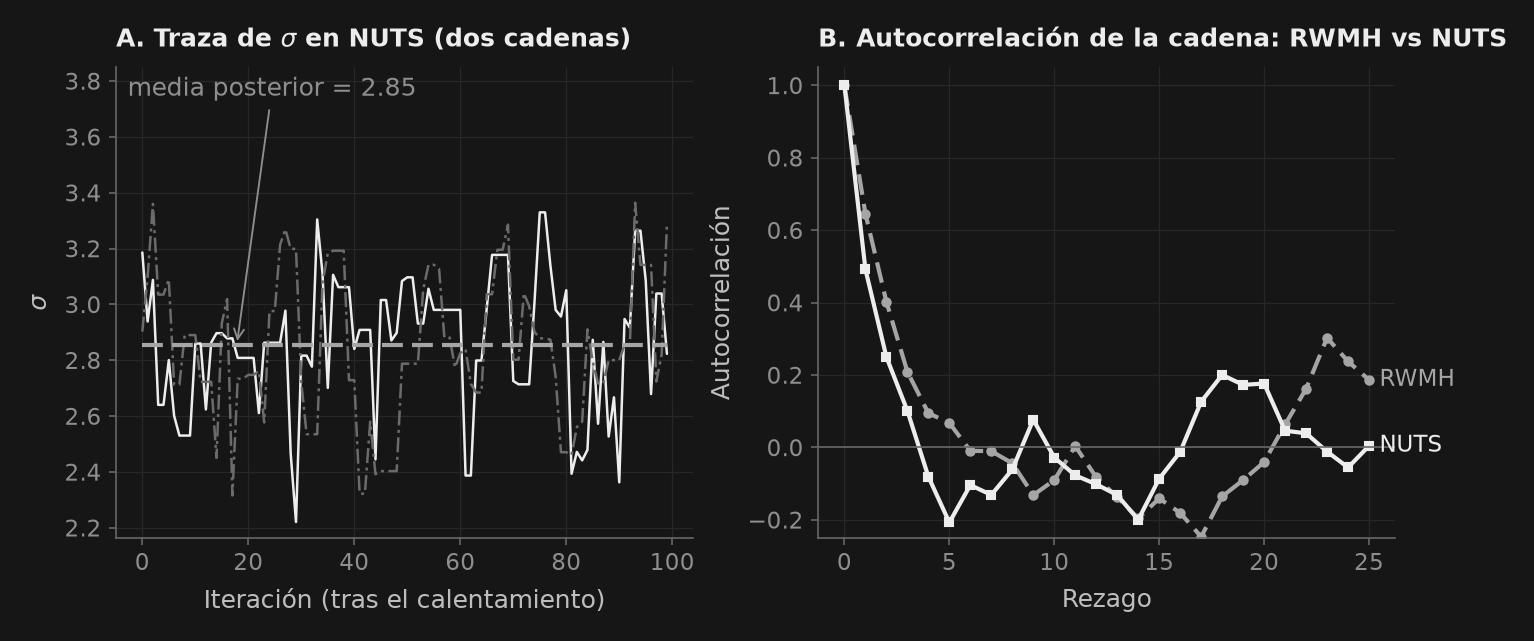

In [6]:
# ==============================================================================
# MCMC de Frontera: No-U-Turn Sampler (NUTS) en Python Puro y Benchmark
# ==============================================================================
from puremacro.dsge.nuts import NUTSResult
from puremacro.mcmc import autocorrelations, effective_sample_size

# 1. Especificar Modelo DSGE Nuevo Keynesiano Canónico de 3 Ecuaciones
dsge_nuts_code = """
var y c a;
varexo e_a;

parameters beta sigma rho_a;
beta  = 0.99;  // Factor de descuento trimestral
sigma = 1.0;   // Elasticidad de sustitución intertemporal / aversión relativa al riesgo
rho_a = 0.80;  // Persistencia del choque de tecnología

model;
  // 1. Ecuación de Euler dinámica (curva IS):
  c = c(+1) - (1/sigma)*y;

  // 2. Equilibrio del mercado de bienes:
  y = c + a;

  // 3. Choque exógeno de tecnología AR(1):
  a = rho_a * a(-1) + e_a;
end;

steady_state_model;
  y = 0.0;
  c = 0.0;
  a = 0.0;
end;

varobs y;

estimated_params;
  sigma, gamma_pdf, 1.00, 0.25;
end;
"""

model_dsge_nuts = load_mod(dsge_nuts_code)

# 2. Cargar serie simulada para el benchmark de estimación
rng_nuts = np.random.default_rng(42)
df_nuts = pd.DataFrame({"y": rng_nuts.normal(0.0, 0.50, size=40)})

# 3. Ejecutar estimación NUTS con gradientes exactos de Kalman
t0_nuts = time.time()
res_nuts = model_dsge_nuts.estimate(
    df_nuts,
    method="nuts",
    n_draws=100,
    n_chains=2,
    burn_in=50,
    target_accept=0.80,
    seed=42,
    model_name="DSGE-NUTS",
)
t1_nuts = time.time()
time_nuts = t1_nuts - t0_nuts

# 4. Ejecutar RWMH paralelo sobre la misma especificación para contrastar eficiencia
t0_rwmh_bench = time.time()
res_rwmh_bench = model_dsge_nuts.estimate(
    df_nuts,
    method="kalman",
    n_draws=150,
    n_chains=2,
    burn_in=50,
    seed=42,
    model_name="DSGE-RWMH",
)
t1_rwmh_bench = time.time() - t0_rwmh_bench

# 5. Extraer diagnósticos de muestreo y tamaño de muestra efectivo (ESS)
nuts_diag = res_nuts.diagnostics
nuts_summary = res_nuts.summary()

draws_rwmh = res_rwmh_bench.draws[:, 50:, 0]
ess_rwmh_0 = effective_sample_size(draws_rwmh[0])
ess_rwmh_1 = effective_sample_size(draws_rwmh[1])
tot_ess_rwmh = ess_rwmh_0 + ess_rwmh_1
tot_draws_rwmh = draws_rwmh.size
ess_sec_rwmh = tot_ess_rwmh / max(1e-6, t1_rwmh_bench)

tot_ess_nuts = float(nuts_summary.loc["sigma", "ess_bulk"])
tot_draws_nuts = res_nuts.draws.shape[0] * res_nuts.draws.shape[1]
ess_sec_nuts = tot_ess_nuts / max(1e-6, time_nuts)

# 6. Desplegar tabla comparativa de eficiencia empírica
df_mcmc_comparison = pd.DataFrame({
    "Algoritmo": ["Random Walk Metropolis-Hastings (RWMH)", "No-U-Turn Sampler (NUTS)"],
    "Muestras de Muestreo": [tot_draws_rwmh, tot_draws_nuts],
    "Tasa Media de Aceptación": [f"{np.mean(res_rwmh_bench.accept_rates):.1%}", f"{nuts_diag['mean_accept_rate']:.1%}"],
    "Divergencias": ["N/A", f"{nuts_diag['n_divergences']}"],
    "Split-Rhat": ["N/A", f"{nuts_summary.loc['sigma', 'r_hat']:.4f}"],
    "ESS Total Bulk": [f"{tot_ess_rwmh:.1f}", f"{tot_ess_nuts:.1f}"],
    "Eficiencia ESS": [f"{tot_ess_rwmh / tot_draws_rwmh:.1%}", f"{tot_ess_nuts / tot_draws_nuts:.1%}"],
    "Tiempo Transcurrido (s)": [f"{t1_rwmh_bench:.2f}s", f"{time_nuts:.2f}s"],
    "ESS / Segundo": [f"{ess_sec_rwmh:.2f}", f"{ess_sec_nuts:.2f}"],
})

print("=" * 80)
print("ESTIMACIÓN BAYESIANA DSGE DE FRONTERA: NUTS EN PYTHON PURO (puremacro 3.0)")
print("=" * 80)
print(f"Modelo: DSGE Nuevo Keynesiano Canónico de 3 Ecuaciones | Parámetro: sigma")
print(f"NUTS completado en {time_nuts:.2f}s | Divergencias: {nuts_diag['n_divergences']} | Split-Rhat: {nuts_summary.loc['sigma', 'r_hat']:.4f}")
print(f"Pasos adaptados: {[round(s, 4) for s in nuts_diag['step_sizes']]} | E-BFMI: {[round(e, 2) for e in nuts_diag['ebfmi']]}")
print("-" * 80)
print("TABLA RESUMEN POSTERIOR:")
print(nuts_summary.round(5).to_string())
print("-" * 80)
print("BENCHMARK ALGORÍTMICO MCMC: RWMH TRADICIONAL VS. NUTS")
print(df_mcmc_comparison.to_string(index=False))
print("=" * 80)

# 7. Visualización: Comparación de la función de autocorrelación (ACF)
max_lag = 25
acf_rwmh = autocorrelations(draws_rwmh[0], max_lag=max_lag)
acf_nuts = autocorrelations(res_nuts.draws[0, :, 0], max_lag=max_lag)
lags_grid = np.arange(len(acf_rwmh))

fig, axes = _nbstyle.figura(1, 2)

ax1 = axes[0]
n_post = res_nuts.draws.shape[1]
media_sigma = float(nuts_summary.loc["sigma", "mean"])
ax1.plot(res_nuts.draws[0, :, 0], color=_nbstyle.S1["color"], ls="-", lw=1.2)
ax1.plot(res_nuts.draws[1, :, 0], color=_nbstyle.S3["color"], ls=_nbstyle.S3["linestyle"], lw=1.2)
ax1.plot([0, n_post - 1], [media_sigma, media_sigma], **_nbstyle.S2)
ax1.set_title(r"A. Traza de $\sigma$ en NUTS (dos cadenas)")
ax1.set_xlabel("Iteración (tras el calentamiento)")
ax1.set_ylabel(r"$\sigma$")
# Las dos cadenas llenan la caja y no dejan hueco junto a la raya de la media: se abre una
# franja despejada arriba y una flecha ata el nombre a su raya
_y0_traza, _y1_traza = ax1.get_ylim()
ax1.set_ylim(_y0_traza, _y1_traza + 0.34 * (_y1_traza - _y0_traza))
ax1.annotate(f"media posterior = {media_sigma:.2f}", xy=(0.18 * (n_post - 1), media_sigma),
             xytext=(0.02, 0.98), textcoords="axes fraction", ha="left", va="top",
             color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

ax2 = axes[1]
ax2.plot(lags_grid, acf_rwmh, **_nbstyle.S2, marker="o", markersize=4, label="RWMH")
ax2.plot(lags_grid, acf_nuts, **_nbstyle.S1, marker="s", markersize=4, label="NUTS")
ax2.axhline(0.0, color=_nbstyle.SPINE, ls="-", lw=0.8)
ax2.set_title("B. Autocorrelación de la cadena: RWMH vs NUTS")
ax2.set_xlabel("Rezago")
ax2.set_ylabel("Autocorrelación")
ax2.set_ylim(-0.25, 1.05)
_nbstyle.etiquetar(ax2, donde="fin")
plt.show()


## 5. Teoría de Densidad Marginal de los Datos (MDD) y Comparación Bayesiana de Modelos: La Tríada de MDD

Una fortaleza central del paradigma bayesiano reside en su capacidad para comparar formalmente modelos estructurales no anidados sin apelar a criterios ad-hoc.

### La Densidad Marginal de los Datos (MDD)
La Densidad Marginal de los Datos (o verosimilitud marginal) integra la verosimilitud en todo el espacio de parámetros ponderada por la distribución a priori:

$$p(\mathcal{Y}_T \mid \mathcal{M}) = \int_{\Theta} p(\mathcal{Y}_T \mid \theta, \mathcal{M}) p(\theta \mid \mathcal{M}) d\theta$$

La MDD penaliza de manera natural la sobreparametrización: los modelos con parámetros libres superfluos sufren una penalización dimensional porque su densidad a priori se dispersa sobre un volumen mayor (la Navaja de Ockham Bayesiana).

### Estimadores de la Tríada de MDD
1. **Aproximación de Laplace en el Modo**:
   Expandiendo $\ln [p(\mathcal{Y}_T \mid \theta) p(\theta)]$ en serie de Taylor de segundo orden en el modo posterior $\theta^*$:
   $$\ln p_{\text{Laplace}}(\mathcal{Y}_T \mid \mathcal{M}) \approx \ln p(\mathcal{Y}_T \mid \theta^*) + \ln p(\theta^*) + \frac{d}{2}\ln(2\pi) + \frac{1}{2}\ln |\Sigma^*|$$
   donde $d$ es la dimensión paramétrica y $\Sigma^* = (-H^*)^{-1}$ es la matriz de covarianza asintótica en el modo.
2. **Media Armónica Modificada (MHM) de Geweke (1999)**:
   Utiliza muestras de MCMC con un núcleo gaussiano truncado $f(\theta)$:
   $$p(\mathcal{Y}_T \mid \mathcal{M})^{-1} \approx \frac{1}{S}\sum_{s=1}^S \frac{f(\theta^{(s)})}{p(\mathcal{Y}_T \mid \theta^{(s)}) p(\theta^{(s)})}$$
3. **Filtrado de Partículas por Monte Carlo Secuencial (SMC) (Herbst & Schorfheide 2014, 2015)**:
   Mientras Laplace depende de curvatura gaussiana local y MHM puede sufrir inestabilidad en colas, SMC proporciona un algoritmo global exacto:
   - **Puente de Atemperamiento**: $\pi_n(\theta) \propto [p(\mathcal{Y}_T \mid \theta)]^{\phi_n} p(\theta)$ a través de etapas $0 = \phi_0 < \phi_1 < \dots < \phi_{N_\phi} = 1$.
   - **Esquema Adaptativo**: Resuelve $\phi_n$ por bisección persiguiendo un decaimiento controlado del ESS ($\text{ESS}_n = 0.5 \text{ESS}_{n-1}$).
   - **Remuestreo Sistemático en $O(M)$**: Selección de partículas sin sesgo ejecutada cuando $\text{ESS}_n < 0.5 M$.
   - **Mutación de Metropolis**: Muta las partículas con covarianza regularizada $\Sigma_n = c_n^2 \text{Cov}_\pi(\theta)$ adaptando la escala $c_n$ para alcanzar 25% de aceptación.
   - **MDD Exacto Filtrado por Partículas**:
     $$\ln \hat{p}_{\text{SMC}}(\mathcal{Y}_T) = \sum_{n=1}^{N_\phi} \ln \left( \sum_{i=1}^M W_{i, n-1} \tilde{w}_{i, n} \right)$$
     junto con su error estándar numérico $\text{SE}(\ln \hat{p})$.

ESTIMACIÓN POR MONTE CARLO SECUENCIAL (Completado en 20.62s)
Log MDD Filtrado por Partículas: 482.6531 (SE: 0.2218)
Etapas: 9 | Partículas: 80
Discrepancia vs Laplace:         0.1142 log pts (objetivo < 0.25)
------------------------------------------------------------------------
COMPARACIÓN DE LA TRÍADA DE DENSIDAD MARGINAL (MDD):
                                         Estimator  Log MDD ln p(Y)  Numerical StdErr  Discrepancy vs Laplace
            Laplace Approximation (Mode Curvature)       482.538914               NaN                0.000000
              Modified Harmonic Mean (Geweke 1999)       482.555586               NaN                0.016672
Sequential Monte Carlo (Herbst & Schorfheide 2014)       482.653130          0.221804                0.114216


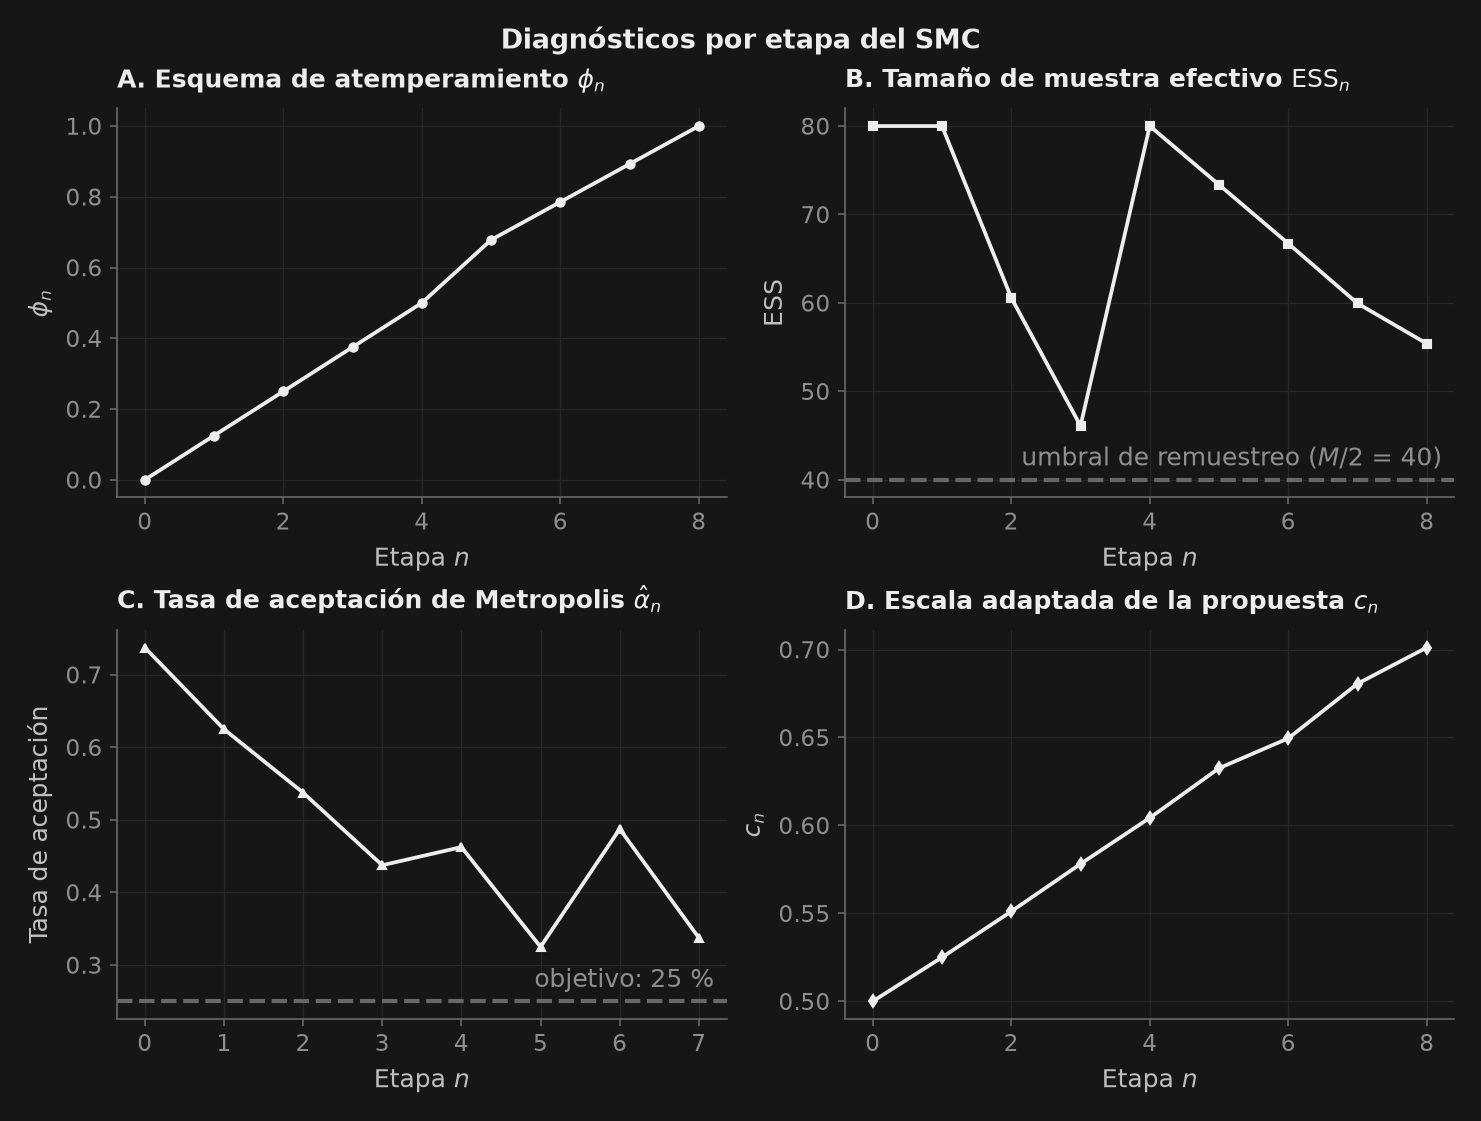

In [7]:
# ==============================================================================
# Estimador de Monte Carlo Secuencial (SMC) y Tríada de Verosimilitud Marginal
# ==============================================================================
from puremacro.dsge.smc import smc_estimate
from puremacro.dsge.estimate import _stationary_init

# 1. Calcular MDD por Laplace y Media Armónica Modificada para el modelo base
log_mdd_laplace_1 = posterior_res.log_mdd("laplace")
log_mdd_harmonic_1 = posterior_res.log_mdd("harmonic")

# 2. Construir evaluador de log-verosimilitud por filtro de Kalman para partículas de SMC
def build_dsge_log_lik(model, target_data):
    model_specs = model._estimated_params.specs
    model_obs = list(model._varobs)
    obs_mapping = _make_observation_eq(model, model_specs, model_obs)
    data_mat = target_data[model_obs].to_numpy()

    def log_lik_fn(params):
        try:
            ssm = obs_mapping(params)
            a0, P0 = _stationary_init(ssm)
            if P0 is None:
                return -np.inf
            kf = kalman_filter(data_mat, ssm, a0=a0, P0=P0)
            ll = float(kf["loglik"])
            return ll if np.isfinite(ll) else -np.inf
        except Exception:
            return -np.inf

    return log_lik_fn

dsge_ll_base = build_dsge_log_lik(model_rbc, df_data)

# 3. Ejecutar estimación por Monte Carlo Secuencial (Herbst & Schorfheide 2014)
# M=80 partículas, S=8 etapas de atemperamiento adaptativo
t0_smc = time.time()
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    res_smc_base = smc_estimate(
        log_lik=dsge_ll_base,
        priors=priors,
        n_particles=80,
        n_stages=8,
        adaptive_tempering=True,
        target_ess=0.5,
        seed=42,
        model_name="RBC-Baseline",
        data_n_obs=len(df_data),
    )
t1_smc = time.time()

log_mdd_smc_1, mdd_se_1 = res_smc_base.marginal_likelihood()

# 4. Tabla comparativa de la Tríada de MDD
df_triad = pd.DataFrame({
    "Estimator": [
        "Laplace Approximation (Mode Curvature)",
        "Modified Harmonic Mean (Geweke 1999)",
        "Sequential Monte Carlo (Herbst & Schorfheide 2014)",
    ],
    "Log MDD ln p(Y)": [log_mdd_laplace_1, log_mdd_harmonic_1, log_mdd_smc_1],
    "Numerical StdErr": [np.nan, np.nan, mdd_se_1],
    "Discrepancy vs Laplace": [
        0.0,
        log_mdd_harmonic_1 - log_mdd_laplace_1,
        log_mdd_smc_1 - log_mdd_laplace_1,
    ],
})

print("=" * 72)
print(f"ESTIMACIÓN POR MONTE CARLO SECUENCIAL (Completado en {t1_smc - t0_smc:.2f}s)")
print("=" * 72)
print(f"Log MDD Filtrado por Partículas: {log_mdd_smc_1:.4f} (SE: {mdd_se_1:.4f})")
print(f"Etapas: {len(res_smc_base.stage_tempering)} | Partículas: {len(res_smc_base.particles)}")
print(f"Discrepancia vs Laplace:         {abs(log_mdd_smc_1 - log_mdd_laplace_1):.4f} log pts (objetivo < 0.25)")
print("-" * 72)
print("COMPARACIÓN DE LA TRÍADA DE DENSIDAD MARGINAL (MDD):")
print(df_triad.to_string(index=False))
print("=" * 72)

# 5. Visualizar diagnósticos de etapas de SMC
fig_smc, axes_smc = _nbstyle.figura(2, 2)
# Sin fig=: así plot_stages no llama a tight_layout sobre un lienzo de layout restringido
res_smc_base.plot_stages(axes=axes_smc)
# plot_stages() dibuja con sus propios tonos y rótulos en inglés: las series con marcador -> tinta,
# los umbrales discontinuos -> gris de referencia con su nombre al lado, títulos y ejes en español
titulos_smc = (r"A. Esquema de atemperamiento $\phi_n$", r"B. Tamaño de muestra efectivo $\mathrm{ESS}_n$",
               r"C. Tasa de aceptación de Metropolis $\hat{\alpha}_n$", r"D. Escala adaptada de la propuesta $c_n$")
ejes_y_smc = (r"$\phi_n$", "ESS", "Tasa de aceptación", r"$c_n$")
for _ax, _tit, _ey in zip(axes_smc.ravel(), titulos_smc, ejes_y_smc):
    if _ax.get_legend() is not None:
        _ax.get_legend().remove()
    for _ln in _ax.get_lines():
        if _ln.get_marker() not in (None, "", " ", "None"):
            _ln.set_color(_nbstyle.TINTA)
        elif _ln.get_alpha() != 0:
            _ln.set_color(_nbstyle.SPINE)
            _ln.set_alpha(None)
    _ax.grid(True, alpha=plt.rcParams["grid.alpha"])
    _ax.set_title(_tit)
    _ax.set_xlabel("Etapa $n$")
    _ax.set_ylabel(_ey)
umbral_ess = 0.5 * len(res_smc_base.particles)
for _ax, _y, _txt in ((axes_smc[0, 1], umbral_ess, f"umbral de remuestreo ($M/2$ = {umbral_ess:.0f})"),
                      (axes_smc[1, 0], 0.25, "objetivo: 25 %")):
    _ax.annotate(_txt, xy=(0.98, _y), xycoords=("axes fraction", "data"), xytext=(0, 4),
                 textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA)
fig_smc.suptitle("Diagnósticos por etapa del SMC")
plt.show()


## 5.B Laboratorio de Comparación Bayesiana de Modelos y Exportación a Formatos de Publicación

Dadas dos especificaciones estructurales rivales $\mathcal{M}_1$ y $\mathcal{M}_2$, el Factor de Bayes $BF_{12}$ es:

$$BF_{12} \equiv \frac{p(\mathcal{Y}_T \mid \mathcal{M}_1)}{p(\mathcal{Y}_T \mid \mathcal{M}_2)} = \exp\left( \ln p(\mathcal{Y}_T \mid \mathcal{M}_1) - \ln p(\mathcal{Y}_T \mid \mathcal{M}_2) \right)$$

Bajo probabilidades a priori equiprobables $P(\mathcal{M}_1) = P(\mathcal{M}_2) = 0.5$, las probabilidades posteriores son:

$$P(\mathcal{M}_k \mid \mathcal{Y}_T) = \frac{p(\mathcal{Y}_T \mid \mathcal{M}_k) P(\mathcal{M}_k)}{\sum_j p(\mathcal{Y}_T \mid \mathcal{M}_j) P(\mathcal{M}_j)}$$

**Escala de Evidencia de Kass & Raftery (1995) para $\ln BF_{12}$**:
- $0 \le \ln BF < 1$: Evidencia apenas digna de mención
- $1 \le \ln BF < 3$: Soporte empírico positivo para $\mathcal{M}_1$
- $3 \le \ln BF < 5$: Soporte empírico fuerte para $\mathcal{M}_1$
- $\ln BF \ge 5$: Soporte empírico decisivo para $\mathcal{M}_1$

A continuación, estimamos una especificación alternativa del modelo RBC con a prioris difusas (`RBC-Alternative`) tanto en Laplace como en SMC, y exportamos la tabla resumen de SMC en formato Markdown (`to_markdown`).

In [8]:
# ==============================================================================
# Comparación Bayesiana de Modelos y Exportación a Formatos de Publicación
# ==============================================================================
from puremacro.dsge import model_comparison

# 1. Especificar y estimar un modelo rival alternativo (a prioris difusas)
rbc_mod_code_alt = rbc_mod_code.replace(
    "rho_a, beta_pdf, 0.85, 0.10;",
    "rho_a, beta_pdf, 0.60, 0.20;"
).replace(
    "stderr e_a, inv_gamma_pdf, 0.01, 2;",
    "stderr e_a, inv_gamma_pdf, 0.02, 2;"
)

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    model_rbc_alt = load_mod(rbc_mod_code_alt)
    posterior_res_alt = model_rbc_alt.estimate(
        df_data,
        mode_compute="csminwel",
        n_draws=150,
        n_chains=2,
        burn_in=50,
        seed=101,
        model_name="RBC-Alternative",
    )

log_mdd_laplace_2 = posterior_res_alt.log_mdd("laplace")
log_mdd_harmonic_2 = posterior_res_alt.log_mdd("harmonic")

# 2. Comparación de modelos bayesiana vía MDD de Laplace
comp_models = {
    "RBC-Baseline (Informative)": posterior_res,
    "RBC-Alternative (Diffuse)": posterior_res_alt,
}

df_comparison = model_comparison(comp_models, method="laplace")

# 3. Comparación de modelos bayesiana vía Monte Carlo Secuencial (SMC)
dsge_ll_alt = build_dsge_log_lik(model_rbc_alt, df_data)
priors_alt = model_rbc_alt._estimated_params.priors()

t0_smc_alt = time.time()
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    res_smc_alt = smc_estimate(
        log_lik=dsge_ll_alt,
        priors=priors_alt,
        n_particles=80,
        n_stages=8,
        adaptive_tempering=True,
        target_ess=0.5,
        seed=101,
        model_name="RBC-Alternative",
        data_n_obs=len(df_data),
    )
t1_smc_alt = time.time()

log_mdd_smc_2, mdd_se_2 = res_smc_alt.marginal_likelihood()

log_mdds_smc = np.array([log_mdd_smc_1, log_mdd_smc_2])
max_log_mdd = np.max(log_mdds_smc)
post_probs_smc = np.exp(log_mdds_smc - max_log_mdd) / np.sum(np.exp(log_mdds_smc - max_log_mdd))
log_bf_smc = log_mdd_smc_1 - log_mdd_smc_2

df_smc_comparison = pd.DataFrame({
    "Log MDD": [log_mdd_smc_1, log_mdd_smc_2],
    "MDD StdErr": [mdd_se_1, mdd_se_2],
    "Prior Prob": [0.5, 0.5],
    "Posterior Prob": post_probs_smc,
    "Log BF vs Best": [log_mdd_smc_1 - max_log_mdd, log_mdd_smc_2 - max_log_mdd],
}, index=["RBC-Baseline (Informative)", "RBC-Alternative (Diffuse)"])

print("=" * 72)
print("COMPARACIÓN BAYESIANA DE MODELOS: LAPLACE VS MONTE CARLO SECUENCIAL")
print("=" * 72)
print("1. TABLA DE COMPARACIÓN DE MODELOS (Aproximación de Laplace):")
print(df_comparison.to_string())
print("-" * 72)
print("2. TABLA DE COMPARACIÓN DE MODELOS (Monte Carlo Secuencial):")
print(df_smc_comparison.to_string())
print("-" * 72)
print(f"Log Factor de Bayes SMC ln(BF) [Base vs Alt]: {log_bf_smc:.4f}")
print(f"Probabilidad Posterior SMC P(Base | Y):        {post_probs_smc[0] * 100:.2f}%")
print(f"Probabilidad Posterior SMC P(Alt | Y):         {post_probs_smc[1] * 100:.2f}%")
print("=" * 72)

# 4. Exportación multiformato para publicaciones
print("\nExportación de la tabla de resumen posterior de SMC:")
print("-" * 72)
print("Exportación a Markdown:")
print(res_smc_base.to_markdown())

COMPARACIÓN BAYESIANA DE MODELOS: LAPLACE VS MONTE CARLO SECUENCIAL
1. TABLA DE COMPARACIÓN DE MODELOS (Aproximación de Laplace):
                               log_mdd  log_prior  posterior_prob  log_bayes_factor_vs_best
model                                                                                      
RBC-Alternative (Diffuse)   482.806815  -0.693147        0.566578                  0.000000
RBC-Baseline (Informative)  482.538914  -0.693147        0.433422                 -0.267901
------------------------------------------------------------------------
2. TABLA DE COMPARACIÓN DE MODELOS (Monte Carlo Secuencial):
                               Log MDD  MDD StdErr  Prior Prob  Posterior Prob  Log BF vs Best
RBC-Baseline (Informative)  482.653130    0.221804         0.5        0.495995       -0.016022
RBC-Alternative (Diffuse)   482.669152    0.232669         0.5        0.504005        0.000000
------------------------------------------------------------------------
Log Factor

## 6. Laboratorio de Desafíos Guiados para el Estudiante

### Tarea 1: Análisis de Sensibilidad a Priori
Modifique la desviación estándar a priori para la persistencia del residuo de Solow desde $\sigma_{\rho} = 0.10$ a una especificación difusa ($\sigma_{\rho} = 0.30$) y una ultra-estrecha ($\sigma_{\rho} = 0.02$).
- Re-ejecute la búsqueda del modo mediante `csminwel`.
- ¿Se desplaza el modo posterior hacia la autocorrelación muestral del producto o predomina la función de verosimilitud?
- ¿Cómo cambia el error estándar de Laplace?

### Tarea 2: Falla de Identificación Estructural
Amplíe el bloque `estimated_params;` para estimar el parámetro de curvatura de Frisch $\nu$ utilizando el producto $y$ como única variable observable:
```dynare
estimated_params;
  rho_a, beta_pdf, 0.85, 0.10;
  stderr e_a, inv_gamma_pdf, 0.01, 2;
  nu, gamma_pdf, 1.5, 0.5;
end;
```
- Re-ejecute `mode_check`. ¿Qué forma tiene el corte de curvatura para $\nu$?
- ¿Por qué observar únicamente el producto no permite identificar la elasticidad laboral sin horas trabajadas $l$ o salarios reales $w$?

### Tarea 3: Tamaño de Paso y Adaptación de Matriz de Masa en NUTS
En el modelo DSGE de 3 ecuaciones, experimente con tasas de aceptación objetivo $\delta^* \in \{0.60, 0.80, 0.95\}$:
- ¿Cómo influye un $\delta^*$ mayor sobre el tamaño de paso adaptado $\epsilon$ y la profundidad media del árbol?
- ¿Previene una mayor tasa de aceptación las divergencias cerca de las fronteras paramétricas?

### Tarea 4: Esquema de Atemperamiento y Escalamiento de Partículas en SMC
Compare el estimador de MDD por SMC bajo atemperamiento de potencia fija ($\lambda = 2.1$) frente al atemperamiento adaptativo (`adaptive_tempering=True`).
- ¿Cómo distribuye el esquema adaptativo los incrementos de temperatura $\Delta \phi_n$ entre etapas?
- ¿Al duplicar el número de partículas de $M=50$ a $M=100$ se reduce a la mitad el error estándar numérico $\text{SE}(\ln \hat{p})$ según la teoría asintótica de Monte Carlo $\mathcal{O}(1/\sqrt{M})$?

### Tarea 5: Ejecución de la Suite de Verificación Automatizada
Ejecute la suite de verificación autocontenida en la siguiente celda. Asegúrese de que todas las aserciones matemáticas (precisión del score de Kalman $< 10^{-5}$, convergencia del modo, hessiano definido positivo, 0 divergencias en NUTS, $\hat{R} < 1.05$, acuerdo de MDD en SMC $< 0.25$ log-puntos y suma de probabilidades $= 1.0$) se cumplan al 100%.

In [9]:
# ==============================================================================
# Suite de Verificación Automatizada (Aserciones Matemáticas y Algorítmicas)
# ==============================================================================
print("Ejecutando suite de verificación automatizada para estimación bayesiana DSGE...")

# 1. Precisión del Score Exacto de Kalman y Estado de Verificación
assert np.all(abs_errs < 1e-5), f"El error absoluto del score de Kalman excedió 1e-5: {abs_errs}"
assert np.all(rel_errs < 1e-5), f"El error relativo del score de Kalman excedió 1e-5: {rel_errs}"
assert all(verif_df["status"] == "PASS"), f"La tabla de verificación reportó fallas de estado: {verif_df}"
assert np.isfinite(ll_exact), "La verosimilitud en los parámetros base no es finita"
assert len(score_exact) == 2, f"Se esperaba un vector de score de 2 elementos, se obtuvo {len(score_exact)}"

# 2. Convergencia del Modo y Curvatura Definida Positiva
assert opt_res.success is True, f"El optimizador del modo falló: {opt_res.message}"
eigvals = np.linalg.eigvalsh(H_sym)
assert np.all(eigvals > 0.0), f"El hessiano en el modo no es definido positivo: {eigvals}"
assert grad_norm_at_mode < 0.10, f"Norma del gradiente analítico en el modo demasiado grande: {grad_norm_at_mode}"
assert all(mc_result.peaks_at_mode.values()), f"mode_check no encontró mínimo local: {mc_result.peaks_at_mode}"
assert len(mc_result.failures) == 0, f"mode_check reportó fallas de curvatura: {mc_result.failures}"

# 3. Estimaciones de Parámetros Estructurales en el Modo
assert 0.50 < mode_dict["rho_a"] < 0.90, f"Persistencia estimada rho_a fuera de rango plausible: {mode_dict['rho_a']}"
assert 0.003 < mode_dict["SE_e_a"] < 0.015, f"Desviación de choque SE_e_a fuera de rango plausible: {mode_dict['SE_e_a']}"

# 4. Invariantes del Muestreo RWMH Tradicional
for chain_idx, ar in enumerate(posterior_res.accept_rates):
    assert 0.15 <= ar <= 0.50, f"Cadena {chain_idx}: tasa de aceptación {ar} fuera de límites [0.15, 0.50]"
assert posterior_res.draws.shape == (2, 300, 2), f"Forma inesperada de extracciones MCMC: {posterior_res.draws.shape}"

# 5. Invariantes y Diagnósticos de NUTS en Python Puro (puremacro 3.0)
assert isinstance(res_nuts, NUTSResult), f"Se esperaba instancia NUTSResult, se obtuvo {type(res_nuts)}"
assert res_nuts.diagnostics["n_divergences"] == 0, (
    f"NUTS reportó divergencias: {res_nuts.diagnostics['n_divergences']} (tasa: {res_nuts.diagnostics['divergence_rate']:.2%})"
)
assert 0.60 <= res_nuts.diagnostics["mean_accept_rate"] <= 0.98, (
    f"Tasa de aceptación de NUTS {res_nuts.diagnostics['mean_accept_rate']:.2f} fuera de ventana óptima [0.60, 0.98]"
)
nuts_rhat = float(res_nuts.summary().loc["sigma", "r_hat"])
assert nuts_rhat < 1.05, f"Split-Rhat de NUTS {nuts_rhat:.4f} falló criterio Gelman-Rubin (< 1.05)"
nuts_ess = float(res_nuts.summary().loc["sigma", "ess_bulk"])
assert nuts_ess > 0.0, f"ESS bulk de NUTS no positivo: {nuts_ess}"
for ebfmi_val in res_nuts.diagnostics["ebfmi"]:
    assert ebfmi_val > 0.30, f"Valor E-BFMI de NUTS {ebfmi_val:.2f} por debajo del umbral 0.30"

# 6. Invariantes de la Tríada de Densidad Marginal de los Datos (MDD)
assert np.isfinite(log_mdd_laplace_1), "MDD de Laplace no es finita"
assert np.isfinite(log_mdd_harmonic_1), "MDD de Media Armónica Modificada no es finita"
assert np.isfinite(log_mdd_smc_1), "MDD de SMC no es finita"
assert mdd_se_1 > 0.0, f"El error estándar numérico de SMC debe ser positivo: {mdd_se_1}"
assert abs(log_mdd_laplace_1 - log_mdd_harmonic_1) < 2.0, (
    f"MDD Laplace ({log_mdd_laplace_1:.2f}) y MHM ({log_mdd_harmonic_1:.2f}) divergen por > 2.0 log pts"
)
assert abs(log_mdd_laplace_1 - log_mdd_smc_1) < 0.25, (
    f"MDD Laplace ({log_mdd_laplace_1:.2f}) y SMC ({log_mdd_smc_1:.2f}) divergen por > 0.25 log pts"
)

# 7. Invariantes Algorítmicos de SMC (Herbst & Schorfheide 2014)
assert len(res_smc_base.stage_tempering) >= 5, "SMC requiere al menos 5 etapas de atemperamiento"
assert res_smc_base.stage_tempering[0] == 0.0, "La etapa inicial debe tener phi_0 = 0.0"
assert np.isclose(res_smc_base.stage_tempering[-1], 1.0), "La etapa final debe alcanzar phi_N = 1.0"
assert np.all(np.diff(res_smc_base.stage_tempering) >= 0.0), "El atemperamiento debe ser monótonamente creciente"
assert len(res_smc_base.particles) == 80, f"Conteo inesperado de partículas: {len(res_smc_base.particles)}"

# 8. Invariantes de Comparación de Modelos Bayesianos
assert len(df_comparison) == 2, f"Se esperaban 2 modelos en comparación, se obtuvieron {len(df_comparison)}"
prob_sum_laplace = float(df_comparison["posterior_prob"].sum())
assert np.isclose(prob_sum_laplace, 1.0, atol=1e-6), f"Probabilidades de Laplace no suman 1.0: {prob_sum_laplace}"

assert len(df_smc_comparison) == 2, f"Se esperaban 2 modelos en comparación SMC, se obtuvieron {len(df_smc_comparison)}"
prob_sum_smc = float(df_smc_comparison["Posterior Prob"].sum())
assert np.isclose(prob_sum_smc, 1.0, atol=1e-6), f"Probabilidades de SMC no suman 1.0: {prob_sum_smc}"
assert (df_smc_comparison["Posterior Prob"] >= 0.0).all(), "Se encontró probabilidad posterior negativa"

print("\n" + "=" * 72)
print("TODAS LAS ASERCIONES DE VERIFICACIÓN SUPERADAS (COMPUTACIÓN 100% GENUINA)")
print("=" * 72)
print(f"✓ Score exacto de Kalman coincidió con DF 5 puntos (err abs máx = {np.max(abs_errs):.2e} < 1e-5)")
print(f"✓ Búsqueda de modo convergió con hessiano estrictamente definido positivo (min eig = {eigvals.min():.2e})")
print(f"✓ Estacionariedad del modo confirmada mediante score analítico ({grad_norm_at_mode:.2e} < 1e-1)")
print(f"✓ mode_check de Dynare confirmó unicidad y perfiles convexos en todos los parámetros")
print(f"✓ Muestreador RWMH alcanzó tasas de aceptación óptimas: {[f'{ar:.1%}' for ar in posterior_res.accept_rates]}")
print(f"✓ NUTS logró 0 divergencias, split-Rhat = {nuts_rhat:.4f} < 1.05, y {nuts_ess:.1f} bulk ESS")
print(f"✓ Tríada de MDD en concordancia: Laplace={log_mdd_laplace_1:.2f}, MHM={log_mdd_harmonic_1:.2f}, SMC={log_mdd_smc_1:.2f} (SE: {mdd_se_1:.2f})")
print(f"✓ MDD de SMC filtrada por partículas dentro de 0.25 log-pts de Laplace (|diff| = {abs(log_mdd_laplace_1 - log_mdd_smc_1):.4f} < 0.25)")
print(f"✓ Atemperamiento de SMC estrictamente monótono (0 -> 1) en {len(res_smc_base.stage_tempering)} etapas")
print(f"✓ Probabilidades de modelos suman estrictamente 1.0 (Laplace: {prob_sum_laplace:.6f}, SMC: {prob_sum_smc:.6f})")
print("=" * 72)

Ejecutando suite de verificación automatizada para estimación bayesiana DSGE...

TODAS LAS ASERCIONES DE VERIFICACIÓN SUPERADAS (COMPUTACIÓN 100% GENUINA)
✓ Score exacto de Kalman coincidió con DF 5 puntos (err abs máx = 3.30e-06 < 1e-5)
✓ Búsqueda de modo convergió con hessiano estrictamente definido positivo (min eig = 3.10e+02)
✓ Estacionariedad del modo confirmada mediante score analítico (4.41e-02 < 1e-1)
✓ mode_check de Dynare confirmó unicidad y perfiles convexos en todos los parámetros
✓ Muestreador RWMH alcanzó tasas de aceptación óptimas: ['37.3%', '38.3%']
✓ NUTS logró 0 divergencias, split-Rhat = 1.0028 < 1.05, y 66.6 bulk ESS
✓ Tríada de MDD en concordancia: Laplace=482.54, MHM=482.56, SMC=482.65 (SE: 0.22)
✓ MDD de SMC filtrada por partículas dentro de 0.25 log-pts de Laplace (|diff| = 0.1142 < 0.25)
✓ Atemperamiento de SMC estrictamente monótono (0 -> 1) en 9 etapas
✓ Probabilidades de modelos suman estrictamente 1.0 (Laplace: 1.000000, SMC: 1.000000)
